# Hypothesis testing: do promotions increase sales?

In `01_eda` we *saw* a gap — promo days averaged €8,228 vs €5,929 (~+39%). Seeing a gap isn't proving one.
Here we test it formally, the same framework as the diploma's L6: state hypotheses, run a test, decide against alpha,
**and** quantify the effect in euros + effect size so the result is a business statement, not just a p-value.

We load the cleaned data straight from the pipeline output (`data/processed/clean.parquet`) so this notebook always
matches what the model trains on.

### 0. Setup & Load Cleaned Data 

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# clean.parquet is the output of `python src/data_prep.py` (the DVC prepare stage):
# already merged, open-days-only, missing values handled.
df = pd.read_parquet(Path("../data/processed/clean.parquet"))
print("rows:", f"{len(df):,}")

rows: 844,392


### 1. Define the test

- **H0 (null):** mean sales on promo days = mean sales on non-promo days  (mu_promo = mu_no)
- **H1 (alternative):** mean sales on promo days > non-promo days  (one-tailed — we only care if promo *helps*)
- **alpha = 0.05**

We use **Welch's two-sample t-test** (`equal_var=False`) rather than the classic Student's t-test, because the two
groups almost certainly have unequal variance (promo days are more spread out — you saw that in the boxplot).
Welch is the safe default whenever you can't assume equal variances.

In [3]:
promo    = df.loc[df["Promo"] == 1, "Sales"]
no_promo = df.loc[df["Promo"] == 0, "Sales"]

print(f"promo days     : n={len(promo):,}  mean=€{promo.mean():,.0f}  std=€{promo.std():,.0f}")
print(f"non-promo days : n={len(no_promo):,}  mean=€{no_promo.mean():,.0f}  std=€{no_promo.std():,.0f}")

promo days     : n=376,896  mean=€8,228  std=€3,176
non-promo days : n=467,496  mean=€5,929  std=€2,630


### 2. Run the t-test

In [ ]:
# scipy gives a two-sided p-value by default; we want one-sided (H1: promo > no-promo), so we halve the p-value & check the t-statistic points the right way (t > 0).
t_stat, p_two = stats.ttest_ind(promo, no_promo, equal_var=False)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print(f"t-statistic : {t_stat:,.2f}")
print(f"p-value (one-sided): {p_one:.3e}")
print("decision    :", "reject H0" if (p_one < 0.05 and t_stat > 0) else "fail to reject H0")

t-statistic : 356.64
p-value (one-sided): 0.000e+00
decision    : reject H0


### 3. The catch: significance vs. magnitude

With ~840k rows, **p will be ~0 for almost any difference** — huge samples make even trivial gaps "statistically
significant." So a p-value alone is a weak business statement. We add two things that *do* carry meaning:

1. a **95% confidence interval for the euro difference** in means, and
2. **Cohen's d** — the effect size (difference in standard-deviation units), which is sample-size independent.

In [5]:
# 95% CI for the difference in means (Welch). With large n the t-dist ~ normal, so 1.96 is fine.
mean_diff = promo.mean() - no_promo.mean()
se_diff = np.sqrt(promo.var(ddof=1)/len(promo) + no_promo.var(ddof=1)/len(no_promo))
ci_low, ci_high = mean_diff - 1.96*se_diff, mean_diff + 1.96*se_diff

# Cohen's d with pooled standard deviation
n1, n2 = len(promo), len(no_promo)
pooled_sd = np.sqrt(((n1-1)*promo.var(ddof=1) + (n2-1)*no_promo.var(ddof=1)) / (n1+n2-2))
cohens_d = mean_diff / pooled_sd

print(f"mean difference : €{mean_diff:,.0f}")
print(f"95% CI          : €{ci_low:,.0f}  to  €{ci_high:,.0f}")
print(f"Cohen's d       : {cohens_d:.2f}")
print(f"relative lift   : {mean_diff / no_promo.mean() * 100:.1f}%")

mean difference : €2,299
95% CI          : €2,286  to  €2,312
Cohen's d       : 0.80
relative lift   : 38.8%


**Reading Cohen's d:** ~0.8 = large.

### 4. Visual: the difference with its confidence interval

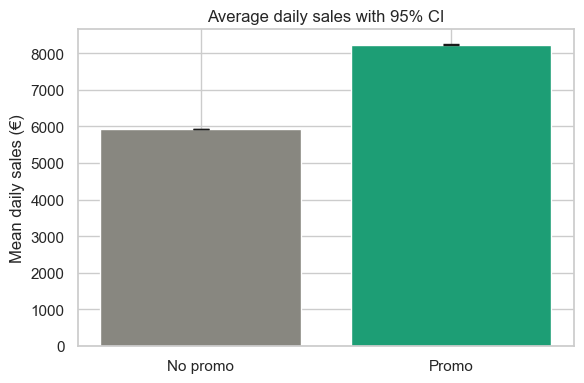

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
means = [no_promo.mean(), promo.mean()]
errs  = [1.96*no_promo.std()/np.sqrt(len(no_promo)), 1.96*promo.std()/np.sqrt(len(promo))]
ax.bar(["No promo", "Promo"], means, yerr=errs, capsize=6, color=["#888780", "#1D9E75"])
ax.set_ylabel("Mean daily sales (€)")
ax.set_title("Average daily sales with 95% CI")
plt.tight_layout(); plt.show()

### 5. Do store types differ? — one-way ANOVA

A t-test compares two groups. To compare the **four** store types at once, use one-way ANOVA.
- **H0:** all store types have equal mean sales
- **H1:** at least one differs

In [7]:
groups = [g["Sales"].values for _, g in df.groupby("StoreType")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:,.2f}  |  p-value: {p_anova:.3e}")
print("decision:", "at least one store type differs" if p_anova < 0.05 else "no detectable difference")

F-statistic: 6,081.82  |  p-value: 0.000e+00
decision: at least one store type differs


### 6. Business statement 

> *"Promotions raise average daily sales by **€2,299** per store (95% CI €2,286–€2,312), a **38.8%** lift. The effect is
> statistically significant (p < 0.001) **and** practically large (Cohen's d = 0.80), supporting continued investment
> in promotional campaigns."*


Two more insights from this run:

1. **Effect size matters here**: with 376k vs 467k rows, p≈0 was guaranteed — so the d=0.80 and the €2,299 lift (not the p-value) are what make this a real finding.
2. **ANOVA (F=6,082, p≈0)**: store types have genuinely different mean sales — confirms the Type B dominance we saw in EDA isn't noise.